0.1666666661111111


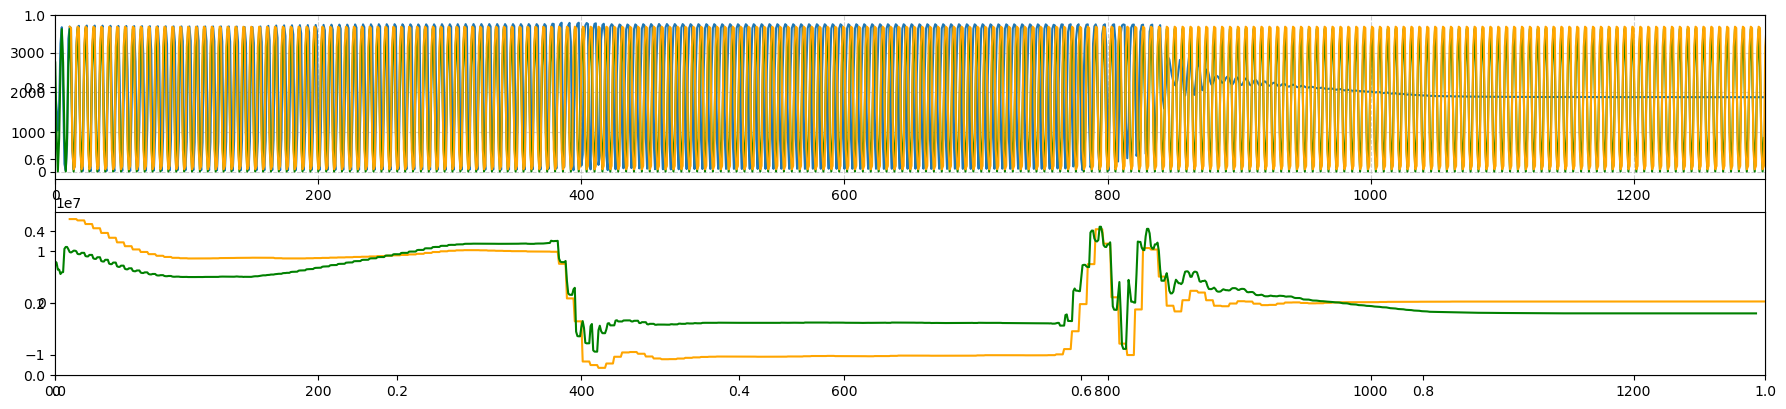

In [1]:
import numpy as np
import matplotlib.pyplot as plt

signal_type=["1010 squarewave",
    "Frequency x2",
    "Frequency x4",
    "Frequency x8",
    "pwm low",
    "pwm high",
    "Phase shift up",
    "Phase shift down",
    "Phase+Frequency"]
fig, ax = plt.subplots(figsize=(18, 4))
plt.subplots_adjust(left=0.04,right=0.99,bottom=0.1,top=1) # Make room for the button

filename = "air_Phase shift up.npy"
y_data = np.load(filename)
N_plot = 1300
ax=plt.subplot(2,1,1)
ax.set_xlim([0,N_plot])
plt.plot(y_data[:N_plot])

# reconstruct template from frequency
N=N_plot
timer_cycle=52./72e6
total_time=(N-1)*timer_cycle
f_sonar=230769.23
N_sonar_cycle=total_time*f_sonar
phase0=3.7
x0=np.linspace(0,N-1,N)
print(f_sonar*timer_cycle)
template=(np.sin(2*np.pi*f_sonar*timer_cycle*x0-phase0)+1)*1800
plt.plot(template,'g')
ax.grid(True, linestyle='--', alpha=0.6)

# sampling template from signal
phase=11
f=6
sample=y_data[phase:phase+f]
r=int(N/f)
y=np.tile(sample,r)
x=np.linspace(0,r*f-1,r*f)
plt.plot(x+phase,y,'orange')

ax=plt.subplot(2,1,2)
ax.set_xlim([0,N_plot])

# correlation 
sig_norm = (y_data - np.mean(y_data))
temp_norm = (sample - np.mean(y_data))
c=np.zeros(r)
for i in range(r):
    j=phase+i*f
    c[i] = np.correlate(sig_norm[j:j+f], temp_norm, mode='valid')[0]
correlation=np.repeat(c,f)
plt.plot(x+phase,correlation,'orange')

temp_norm = (template - np.mean(template))
correlation=np.zeros(N-f)
for i in range(N-f):
    correlation[i] = np.correlate(sig_norm[i:i+f], template[i:i+f], mode='valid')[0]
plt.plot(x0[:-f],correlation,'g')

plt.show()

1187


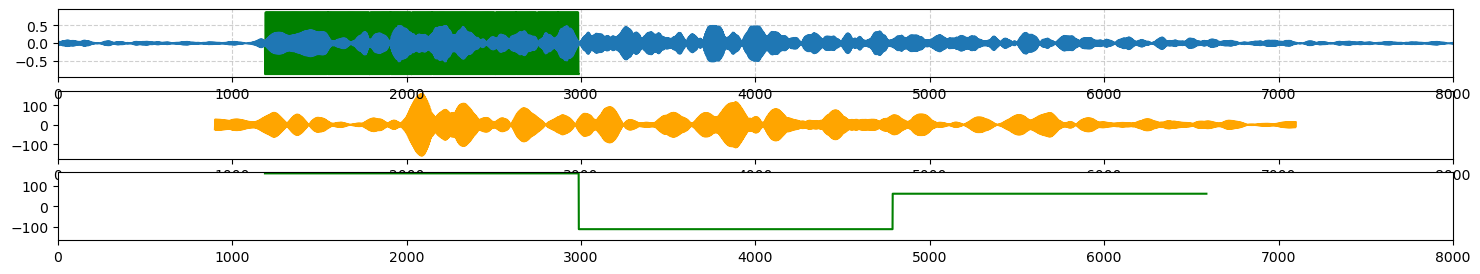

In [261]:
import numpy as np
import matplotlib.pyplot as plt
signal_type=["1010 squarewave",
    "Frequency x2",
    "Frequency x4",
    "Frequency x8",
    "pwm low",
    "pwm high",
    "Phase shift up",
    "Phase shift down",
    "Phase+Frequency"]
plt.figure(figsize=(18, 3))
#plt.subplots_adjust(left=0.04,right=0.99,bottom=0.1,top=1) # Make room for the button
amp=7
filename = "tank_far_cdma_test.npy"
y_data = np.load(filename)
y_data = (y_data - np.mean(y_data))/max(y_data)

N_plot = len(y_data)


# reconstruct template from frequency
cycle_per_digit=20
N_digits=15
N_window=cycle_per_digit*6
timer_cycle=52./72e6
f_sonar=230769.23
x0=np.linspace(0,N_plot-1,N_plot)
N_signal=cycle_per_digit*N_digits*6
t=np.linspace(0,N_window-1,N_window)
template1=np.sin(2*np.pi*f_sonar*timer_cycle*x0[:N_window])
template0=np.sin(2*np.pi*f_sonar*timer_cycle*x0[:N_window]+np.pi)
signal_template=np.zeros(N_signal)
goldcode=[1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0]
for i in range(15):
    if(goldcode[i]):
        signal_template[i*N_window:i*N_window+N_window]=np.sin(2*np.pi*f_sonar*timer_cycle*t+np.pi)
    else:
        signal_template[i*N_window:i*N_window+N_window]=np.sin(2*np.pi*f_sonar*timer_cycle*t)


# correlation 
#sig_norm = (y_data - np.mean(y_data))
#temp_norm = (sample - np.mean(y_data))
ax=plt.subplot(3,1,2)
ax.set_xlim([0,N_plot])
correlation=np.zeros(N_plot-N_signal)
for i in range(N_plot-N_signal):
    correlation[i] = np.correlate(y_data[i:i+N_signal], signal_template, mode='valid')[0]
plt.plot(x0[int(N_signal/2):-int(N_signal/2)],correlation,'orange')

phase_shift=np.argmax(correlation)%(N_window*N_digits)
N_c=int((N_plot-phase_shift)/N_window/N_digits)
ind_max_corr=np.argmax(correlation)
print(ind_max_corr)

ax=plt.subplot(3,1,1)
ax.set_xlim([0,N_plot])
plt.plot(x0[ind_max_corr:ind_max_corr+N_window*N_digits],signal_template,'g')
plt.plot(y_data[:N_plot])
ax.grid(True, linestyle='--', alpha=0.6)


ax=plt.subplot(3,1,3)
ax.set_xlim([0,N_plot])

N_left=N_plot-phase_shift-N_c*N_window*N_digits
correlation=np.zeros(N_c)
for i in range(N_c):
    correlation[i] = np.correlate(y_data[i*N_window*N_digits+phase_shift:(i+1)*N_window*N_digits+phase_shift], signal_template, mode='valid')[0]
signal_level=np.repeat(correlation,N_window*N_digits)
plt.plot(x0[phase_shift:phase_shift+N_window*N_digits*N_c],signal_level,'g')
amp=max(max(signal_level),abs(min(signal_level)))+5
ax.set_ylim([-amp,amp])

plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
N_cycle=50
N_data=20

def apply_hilbert(span):
    taps = [-0.09, 0.0, -0.58, 0.0, 0.58, 0.0, 0.09]
    sum = 0
    for i in range(7):
        sum += span[i] * taps[i];
    return sum
def demodulation(rx_signal,plot):
    # 1. Setup Parameters
    global N_cycle,N_data
    f_sonar=115000
    fs = f_sonar*6        # Sampling frequency (Hz)
    N_plot = len(rx_signal)
    T = float(N_plot)/fs         # Duration (seconds)
    t = np.linspace(0, T, N_plot)
    beta =0
    alpha = 0.005
    N_plot = len(rx_signal)

    n = len(t)
    phase_est = np.zeros(n)
    freq_est = np.zeros(n)
    vco_phase = 0.0

    ref = np.zeros(n)
    i_arm = np.zeros(n)
    q_arm = np.zeros(n)
    error_arr = np.zeros(n)

    current_freq = 115000 # Initial guess
    temp=np.cos(t*current_freq * 2 * np.pi+np.pi/2)

    #rx_complex = hilbert(rx_signal)
    if(1):
        buffer=deque(rx_signal[:7])
        rx_complex=np.zeros(n-6)
        rx_complex[0]=apply_hilbert(buffer)
        for i in range(len(rx_signal)-7):
            buffer.popleft()
            buffer.append(rx_signal[i+7])
            rx_complex[i]=apply_hilbert(buffer)
    else:
        rx_complex=rx_signal[3:]+1j*rx_signal[:-3]
    for k in range(n-3):
        rotated_sample = rx_complex[k] * np.exp(-1j * vco_phase)
        # Local Oscillator (VCO)
        i_arm[k] = rotated_sample.real
        q_arm[k] = rotated_sample.imag
        ref[k]=np.cos(vco_phase)*5
        # Error Detector (I * Q removes the BPSK data modulation)
        # The error is proportional to sin(2 * delta_phase)
        error = i_arm[k] * q_arm[k]/1000000
        error_arr[k] = error
        
        # Loop Filter (PI Controller)
        current_freq += beta * error
        vco_phase += (current_freq * 2 * np.pi / fs) + (alpha * error)
        
        phase_est[k] = vco_phase


    filter=np.array([1,1,1,1,1])
    phase=np.correlate(i_arm,filter,'same')

    preamble=np.repeat(np.array([1,1,1,0,0,1,0,1]),N_cycle*6)
    corr=np.correlate(phase,preamble,"valid")
    i_shift=np.argmax(abs(corr))

    data=np.zeros(N_data)
    grid=np.zeros(N_data)
    for j in range(int(N_data/2)):
        grid[j*2]=-2
    i=i_shift
    while i<N_plot:
        for j in range(N_data):
            for k in range(int(N_cycle)*6):
                data[j]+=i_arm[i+j*N_cycle*6+k]
        break
        i+=1
    data=np.sign(data)
    print(data+1)
    if data[0]<0:
        data=-data
        phase=-phase
    return grid,data,phase,t,i_shift

plt.figure(figsize=(15, 6))

filename = "digital_code.npy"
rx_signal = np.load(filename).astype(float)
rx_signal-=np.mean(rx_signal)
grid,data,correlation,t,i_shift=demodulation(rx_signal,False)

plt.subplot(4,1,1)
plt.plot(t, rx_signal, label="raw data")
plt.plot(t, correlation, label="correlation")
plt.plot(t[i_shift:i_shift+N_cycle*6*N_data], np.repeat(data,N_cycle*6)*5000, label="data bits")
plt.plot(t[i_shift:i_shift+N_cycle*6*N_data], np.repeat(grid,N_cycle*6)*5000, label="grid")
plt.legend(loc='upper left')
plt.xlim(0,t[-1])
plt.tight_layout()

filename = "air_code.npy"
rx_signal = np.load(filename).astype(float)
rx_signal-=np.mean(rx_signal)
grid,data,correlation,t,i_shift=demodulation(rx_signal,False)

plt.subplot(4,1,2)
plt.plot(t, rx_signal, label="raw data")
plt.plot(t, correlation, label="correlation")
plt.plot(t[i_shift:i_shift+N_cycle*6*N_data], np.repeat(data,N_cycle*6)*5000, label="data bits")
plt.plot(t[i_shift:i_shift+N_cycle*6*N_data], np.repeat(grid,N_cycle*6)*5000, label="grid")
plt.legend(loc='upper left')
plt.xlim(0,t[-1])
plt.tight_layout()

filename = "tank_code.npy"
rx_signal = np.load(filename).astype(float)
rx_signal-=np.mean(rx_signal)
grid,data,correlation,t,i_shift=demodulation(rx_signal,False)

plt.subplot(4,1,3)
plt.plot(t, rx_signal, label="raw data")
plt.plot(t, correlation, label="correlation")
plt.plot(t[i_shift:i_shift+N_cycle*6*N_data], np.repeat(data,N_cycle*6)*5000, label="data bits")
plt.plot(t[i_shift:i_shift+N_cycle*6*N_data], np.repeat(grid,N_cycle*6)*5000, label="grid")
plt.legend(loc='upper right')
plt.xlim(0,t[-1])
plt.tight_layout()

filename = "box_code.npy"
rx_signal = np.load(filename).astype(float)
rx_signal-=np.mean(rx_signal)
grid,data,correlation,t,i_shift=demodulation(rx_signal,False)

plt.subplot(4,1,4)
plt.plot(t, rx_signal, label="raw data")
plt.plot(t, correlation, label="correlation")
plt.plot(t[i_shift:i_shift+N_cycle*6*N_data], np.repeat(data,N_cycle*6)*5000, label="data bits")
plt.plot(t[i_shift:i_shift+N_cycle*6*N_data], np.repeat(grid,N_cycle*6)*5000, label="grid")
plt.legend(loc='upper right')
plt.xlim(0,t[-1])
plt.tight_layout()

IndexError: index 6994 is out of bounds for axis 0 with size 6994

<Figure size 1500x600 with 0 Axes>

1115
1254


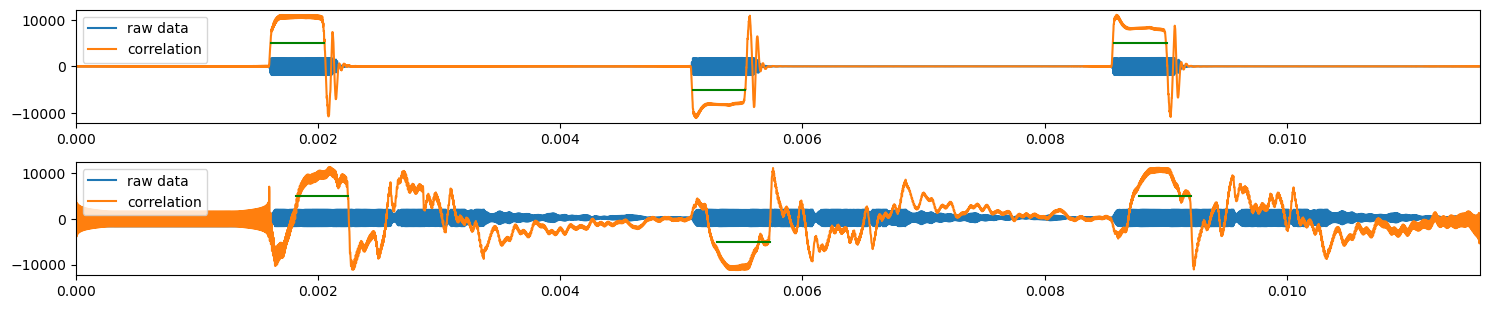

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

import numpy as np
import matplotlib.pyplot as plt
N_cycle=50
N_data=3

def demodulation(rx_signal,plot):
    # 1. Setup Parameters
    global N_cycle,N_data
    f_sonar=115000
    fs = f_sonar*6        # Sampling frequency (Hz)
    N_plot = len(rx_signal)
    T = float(N_plot)/fs         # Duration (seconds)
    t = np.linspace(0, T, N_plot)
    beta =0
    alpha = 0.005
    N_plot = len(rx_signal)

    n = len(t)
    phase_est = np.zeros(n)
    freq_est = np.zeros(n)
    vco_phase = 0.0

    ref = np.zeros(n)
    i_arm = np.zeros(n)
    q_arm = np.zeros(n)
    error_arr = np.zeros(n)

    current_freq = 115000 # Initial guess
    temp=np.cos(t*current_freq * 2 * np.pi+np.pi/2)

    rx_complex = hilbert(rx_signal)
    for k in range(n):
        rotated_sample = rx_complex[k] * np.exp(-1j * vco_phase)
        # Local Oscillator (VCO)
        i_arm[k] = rotated_sample.real
        q_arm[k] = rotated_sample.imag
        ref[k]=np.cos(vco_phase)*5
        # Error Detector (I * Q removes the BPSK data modulation)
        # The error is proportional to sin(2 * delta_phase)
        error = i_arm[k] * q_arm[k]/1000000
        error_arr[k] = error
        if abs(rx_signal[k])>0:
            error=0
        # Loop Filter (PI Controller)
        current_freq += beta * error

        vco_phase += (current_freq * 2 * np.pi / fs) + (alpha * error)
        
        phase_est[k] = vco_phase


    filter=np.array([1,1,1,1,1])
    phase=np.correlate(i_arm,filter,'same')

    preamble=np.repeat(np.array([1]),N_cycle*6)
    corr=np.correlate(phase[:1700],preamble,"valid")
    i_shift=np.argmax(abs(corr))

    print(i_shift)

    data=np.zeros(N_data)
    i=i_shift
    for j in range(N_data):
        for k in range(int(N_cycle)*6):
            data[j]+=i_arm[i+j*N_cycle*6*8+k]
    data=np.sign(data)
    if data[0]<0:
        data=-data
        phase=-phase
    return data,phase,t,i_shift

plt.figure(figsize=(15, 6))

filename = "air_slow.npy"
rx_signal = np.load(filename).astype(float)
rx_signal-=np.mean(rx_signal)
data,correlation,t,i_shift=demodulation(rx_signal,False)

plt.subplot(4,1,1)
plt.plot(t, rx_signal, label="raw data")
plt.plot(t, correlation, label="correlation")
for i in range(N_data):
    plt.plot(t[i_shift+i*N_cycle*6*8:i_shift+i*N_cycle*6*8+N_cycle*6], np.repeat(data[i],N_cycle*6)*5000, 'g-')
plt.legend(loc='upper left')
plt.xlim(0,t[-1])
plt.tight_layout()

filename = "box_slow.npy"
rx_signal = np.load(filename).astype(float)
rx_signal-=np.mean(rx_signal)
data,correlation,t,i_shift=demodulation(rx_signal,False)

plt.subplot(4,1,2)
plt.plot(t, rx_signal, label="raw data")
plt.plot(t, correlation, label="correlation")
for i in range(N_data):
    plt.plot(t[i_shift+i*N_cycle*6*8:i_shift+i*N_cycle*6*8+N_cycle*6], np.repeat(data[i],N_cycle*6)*5000, 'g-')
plt.legend(loc='upper left')
plt.xlim(0,t[-1])
plt.tight_layout()

1884.1856140350876
[2. 0. 2.]


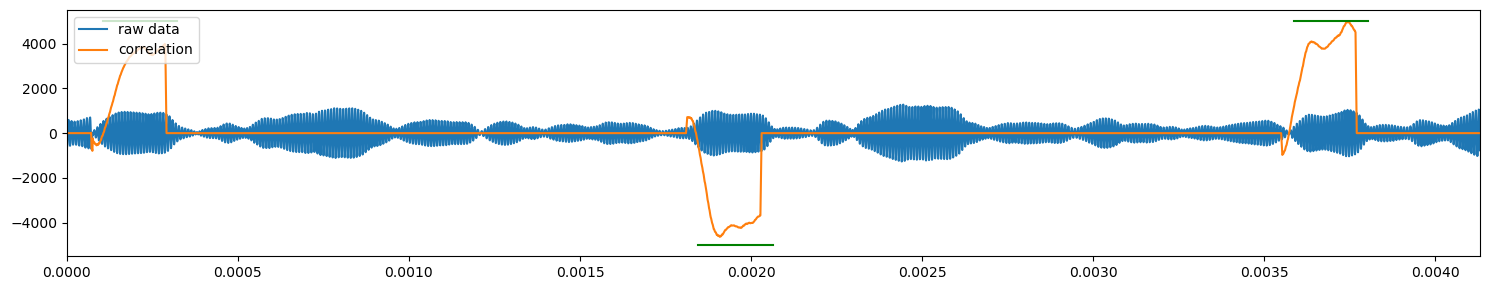

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
N_cycle=25
N_data=3
N_sample=12
def apply_hilbert(span):
    taps = [-0.09, 0.0, -0.58, 0.0, 0.58, 0.0, 0.09]
    sum = 0
    for i in range(7):
        sum += span[i] * taps[i];
    return sum
def demodulation(rx_signal,plot):
    # 1. Setup Parameters
    global N_cycle,N_data
    f_sonar=115000
    fs = f_sonar*N_sample        # Sampling frequency (Hz)
    N_plot = len(rx_signal)
    T = float(N_plot)/fs         # Duration (seconds)
    t = np.linspace(0, T, N_plot)
    beta =0
    alpha = 0.005
    N_plot = len(rx_signal)

    n = len(t)
    phase_est = np.zeros(n)
    freq_est = np.zeros(n)
    vco_phase = 0.0

    ref = np.zeros(n)
    i_arm = np.zeros(n)
    q_arm = np.zeros(n)
    error_arr = np.zeros(n)

    current_freq = 115000 # Initial guess
    #rx_complex = hilbert(rx_signal)

    rx_complex=rx_signal[3:]+1j*rx_signal[:-3]
    for offset in range(N_data):
        for idx in range(300):
            k=100+offset*8*N_cycle*N_sample+idx
            rotated_sample = rx_complex[k] * np.exp(-1j * vco_phase)
            # Local Oscillator (VCO)
            i_arm[k] = rotated_sample.real
            q_arm[k] = rotated_sample.imag
            ref[k]=np.cos(vco_phase)*5
            # Error Detector (I * Q removes the BPSK data modulation)
            # The error is proportional to sin(2 * delta_phase)
            error = i_arm[k] * q_arm[k]/1000000
            error_arr[k] = error
            
            # Loop Filter (PI Controller)
            current_freq += beta * error
            vco_phase += 0.5236 + (alpha * error)
            
            phase_est[k] = vco_phase
        vco_phase+=1099.56


    filter=np.array([1,1,1,1,1])
    phase=np.correlate(i_arm,filter,'same')

    preamble=np.repeat(np.array([1]),N_cycle*N_sample)
    corr=np.correlate(phase[:700],preamble,"valid")
    i_shift=np.argmax(abs(corr))

    data=np.zeros(N_data)
    i=i_shift
    for j in range(N_data):
        for k in range(int(N_cycle)*N_sample):
            data[j]+=i_arm[i+j*N_cycle*N_sample*8+k]
    data=np.sign(data)
    print(data+1)
    if data[0]<0:
        data=-data
        phase=-phase
    return data,phase,t,i_shift

plt.figure(figsize=(15, 3))

filename = "box full sample.npy"
rx_signal = np.load(filename).astype(float)
print(np.mean(rx_signal))
rx_signal-=np.mean(rx_signal)
data,correlation,t,i_shift=demodulation(rx_signal,False)

plt.plot(t, rx_signal, label="raw data")
plt.plot(t, correlation, label="correlation")
for i in range(N_data):
    plt.plot(t[i_shift+i*N_cycle*N_sample*8:i_shift+i*N_cycle*N_sample*8+N_cycle*N_sample], np.repeat(data[i],N_cycle*N_sample)*5000, 'g-')
plt.legend(loc='upper left')
plt.xlim(0,t[-1])
plt.tight_layout()

In [55]:
import numpy as np

def to_cpp(data,array_name, cpp_type="float"):
    # Convert list elements to strings
    elements_str = ', '.join(map(str, data))
    
    # Get the size of the array
    size = len(data)
    
    # Format the C++ array declaration string
    cpp_array_str = f"{cpp_type} {array_name}[{size}] = {{{elements_str}}};"
    
    return cpp_array_str

N=2**5
x=np.linspace(0,2*np.pi,N+1)
c=np.round(np.cos(x)[:-1],6)
s=np.round(np.sin(x)[:-1],6)
print(to_cpp(s,"sin_lut"))
print(to_cpp(c,"cos_lut"))
print(N,0.5236*N/(2*np.pi))

float sin_lut[32] = {0.0, 0.19509, 0.382683, 0.55557, 0.707107, 0.83147, 0.92388, 0.980785, 1.0, 0.980785, 0.92388, 0.83147, 0.707107, 0.55557, 0.382683, 0.19509, 0.0, -0.19509, -0.382683, -0.55557, -0.707107, -0.83147, -0.92388, -0.980785, -1.0, -0.980785, -0.92388, -0.83147, -0.707107, -0.55557, -0.382683, -0.19509};
float cos_lut[32] = {1.0, 0.980785, 0.92388, 0.83147, 0.707107, 0.55557, 0.382683, 0.19509, 0.0, -0.19509, -0.382683, -0.55557, -0.707107, -0.83147, -0.92388, -0.980785, -1.0, -0.980785, -0.92388, -0.83147, -0.707107, -0.55557, -0.382683, -0.19509, -0.0, 0.19509, 0.382683, 0.55557, 0.707107, 0.83147, 0.92388, 0.980785};
32 2.6666729024933247


In [54]:
d_i=round(2**32/12)
print(d_i,round(d_i)*2*np.pi/2**32,2*np.pi/12)

357913941 0.5235987751106594 0.5235987755982988
